# 06_Unsupervised_Model_Development_KMeans

In [4]:
# pip install --upgrade ipywidgets jupyter

In [13]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import umap
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [30]:
# Load the parquet file
INPUT_PATH = '../data/processed/processed_narratives.parquet'
df_narratives = pd.read_parquet(INPUT_PATH)

In [15]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,NaN,Consent provided,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,NaN,Consent provided,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,NaN,Consent provided,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,NaN,Consent provided,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...
4,2020-04-23,Mortgage,Conventional home mortgage,Struggling to pay mortgage,NaN,Rushmore Loan management XXXX will not permit ...,NaN,RUSHMORE LOAN MANAGEMENT SERVICES LLC,AL,36117,NaN,Consent provided,Web,2020-04-27,Closed with explanation,True,N/A,3619130,Rushmore Loan management REDACTED will not per...,rushmore loan management permit applying loan ...


TO DO's:
1. Use distinct colors on UMAP plot

In [22]:
# jpmorgan_count = (
#     df_narratives['processed_narrative']
#     .str.contains(r'\bjpmorgan\b', regex=True, na=False)
#     .sum()
# )
#
# print(f"Records containing 'jpmorgan': {jpmorgan_count:,}")

In [23]:
# company_stopwords = {
#     'one',
#     'chase',
#     'well',
#     'fargo',
#     'capital',
#     'america',
#     'citibank',
#     'citi',
#     'jpmorgan',
#     'navy',
#     'federal',
#     'union'
# }
#
# custom_stopwords = ENGLISH_STOP_WORDS.union(company_stopwords)

In [31]:
# Get TF-IDF weights
tfidf = TfidfVectorizer(
    # stop_words=list(custom_stopwords),
    min_df=10,
    max_df=0.95,
    max_features=20000
)

X_tfidf = tfidf.fit_transform(df_narratives['processed_narrative'])

print(X_tfidf.shape)

(541213, 20000)


In [32]:
# Get top TF-IDF terms
feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_terms = (
    pd.DataFrame({
        'term': feature_names,
        'mean_tfidf': mean_tfidf
    })
    .sort_values('mean_tfidf', ascending=False)
)

top_tfidf_terms.head(25)

,term,mean_tfidf
154,account,0.064684
12547,payment,0.043292
2522,card,0.042419
4086,credit,0.041974
1612,bank,0.040747
19875,would,0.025520
2792,charge,0.024440
17902,time,0.023858
6845,fee,0.023446
17981,told,0.023079


In [33]:
print(X_tfidf.shape)

(541213, 20000)


In [34]:
# Run K-Means mini-batching and add cluster ID's to dataframe
# k = 10

kmeans = MiniBatchKMeans(
    n_clusters=10,
    random_state=42,
    batch_size=1000,
    n_init='auto'
)

clusters = kmeans.fit_predict(X_tfidf)

df_narratives['cluster'] = clusters

df_narratives['cluster'].value_counts().sort_index()

cluster
0     65564
1     23539
2     38696
3     15102
4     56377
5     59491
6     46905
7    140438
8     40406
9     54695
Name: count, dtype: int64

In [35]:
# Print top terms for each cluster
terms = np.array(tfidf.get_feature_names_out())
centroids = kmeans.cluster_centers_

for cluster_num in range(kmeans.n_clusters):
    top_term_indices = centroids[cluster_num].argsort()[::-1][:15]
    top_terms = terms[top_term_indices]

    print(f'\nCluster {cluster_num}')
    print(', '.join(top_terms))


Cluster 0
card, credit, account, charge, bank, balance, would, limit, called, never, received, one, company, told, closed

Cluster 1
fargo, well, account, late, start, investigation, bureau, attached, document, never, want, see, bank, claim, card

Cluster 2
capital, credit, account, one, report, dispute, reporting, consumer, information, act, card, merchant, charge, request, bank

Cluster 3
fee, overdraft, account, navy, transaction, federal, charged, fund, practice, despite, union, charge, balance, credit, insufficient

Cluster 4
payment, late, account, fee, made, credit, interest, due, month, balance, paid, time, statement, pay, mortgage

Cluster 5
check, account, bank, fund, money, america, deposit, told, closed, day, deposited, would, branch, called, checking

Cluster 6
loan, mortgage, escrow, insurance, tax, home, payment, property, company, closing, would, paid, lender, appraisal, rate

Cluster 7
account, bank, money, time, card, would, call, told, day, email, back, received, ca

In [36]:
# Calculate silhouette score
sample_idx = df_narratives.sample(
    n=10000,
    random_state=42
).index

X_sample = X_tfidf[sample_idx]
cluster_sample = df_narratives.loc[sample_idx, 'cluster']

score = silhouette_score(
    X_sample,
    cluster_sample,
    metric='cosine'
)

print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.0202


In [13]:
# Add distance to assigned centroid to dataframe
distances = kmeans.transform(X_tfidf)
assigned_cluster = df_narratives['cluster'].values

df_narratives['distance_to_centroid'] = (
    distances[
        np.arange(len(df_narratives)),
        assigned_cluster
    ]
)

In [15]:
# Get inertia values to use for elbow plot
inertia_values = []

for k in range(5, 21):
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1000
    )

    model.fit(X_tfidf)

    inertia_values.append(model.inertia_)

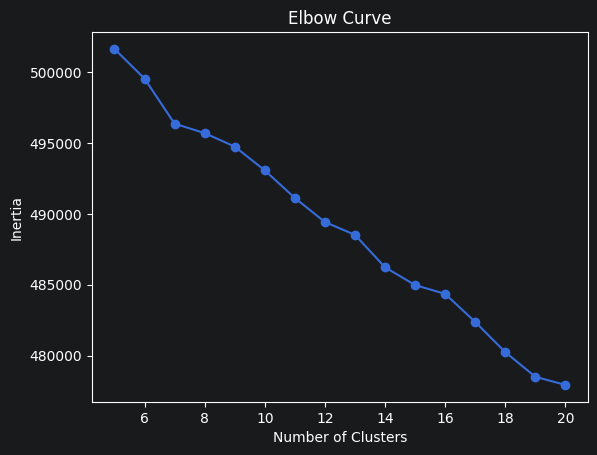

In [16]:
# Make elbow plot
plt.plot(range(5, 21), inertia_values, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [17]:
# Take sample to use for UMAP
sample_size = 20000

sample_idx = df_narratives.sample(
    n=sample_size,
    random_state=42
).index

X_sample = X_tfidf[sample_idx]
cluster_sample = df_narratives.loc[sample_idx, 'cluster']

In [18]:
# Run SVD on 20k sample
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_sample_svd = svd.fit_transform(X_sample)

In [19]:
# Run UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample_svd)

C:\Users\Tony\PyCharm Projects\cfpb_mortgage_complaints\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


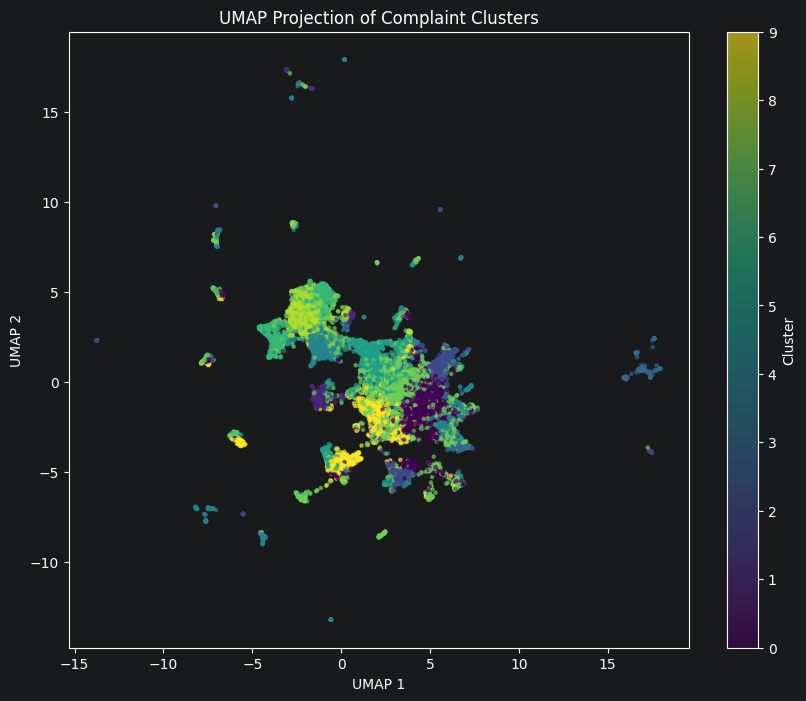

In [20]:
# Plot UMAP
plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cluster_sample,
    s=5,
    alpha=0.6
)

plt.title('UMAP Projection of Complaint Clusters')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster')
plt.show()

## Experimenting with Different Values of K

In [21]:
# # Try different values of k (5, 10, 15, 20)
#
# # Use a sample for silhouette scoring to avoid memory/runtime issues
# sample_size = 10_000
#
# sample_idx = df_narratives.sample(
#     n=sample_size,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [5, 10, 15, 20]
#
# results = []
#
# for k in k_values:
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     cluster_labels = kmeans.fit_predict(X_tfidf)
#
#     sample_labels = cluster_labels[sample_idx]
#
#     sil_score = silhouette_score(
#         X_sample,
#         sample_labels,
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil_score,
#         'inertia': kmeans.inertia_
#     })
#
#     print(f'k={k}, silhouette={sil_score:.4f}, inertia={kmeans.inertia_:.2f}')
#
# k_results = pd.DataFrame(results)
#
# k_results

In [22]:
# # Try different values of k (20, 25, 30)
#
# # Use a sample for silhouette scoring to avoid memory/runtime issues
# sample_size = 10_000
#
# sample_idx = df_narratives.sample(
#     n=sample_size,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [20, 25, 30]
#
# results = []
#
# for k in k_values:
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     cluster_labels = kmeans.fit_predict(X_tfidf)
#
#     sample_labels = cluster_labels[sample_idx]
#
#     sil_score = silhouette_score(
#         X_sample,
#         sample_labels,
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil_score,
#         'inertia': kmeans.inertia_
#     })
#
#     print(f'k={k}, silhouette={sil_score:.4f}, inertia={kmeans.inertia_:.2f}')
#
# k_results = pd.DataFrame(results)
#
# k_results

In [23]:
# # Re-run K-Means with k = 30
# k = 30
#
# kmeans_30 = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# df_narratives['cluster_30'] = kmeans_30.fit_predict(X_tfidf)

In [24]:
# # Get top terms for each cluster
# terms = np.array(tfidf.get_feature_names_out())
#
# for cluster_num in range(k):
#     top_indices = kmeans_30.cluster_centers_[cluster_num].argsort()[::-1][:15]
#     top_terms = terms[top_indices]
#
#     print(f'\nCluster {cluster_num}')
#     print(', '.join(top_terms))

In [25]:
# # Make elbow plot
#
# # If you already have k_results from the previous runs:
# k_results_all = pd.DataFrame({
#     'k': [5, 10, 15, 20, 25, 30],
#     'inertia': [
#         501625.757038,
#         493061.541536,
#         484974.411374,
#         477933.852704,
#         473501.325696,
#         469830.685334
#     ],
#     'silhouette_score': [
#         0.017681,
#         0.020211,
#         0.024968,
#         0.032750,
#         0.034799,
#         0.040312
#     ]
# })
#
# plt.figure(figsize=(8, 5))
#
# plt.plot(
#     k_results_all['k'],
#     k_results_all['inertia'],
#     marker='o'
# )
#
# plt.title('Elbow Plot for MiniBatchKMeans')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia')
# plt.xticks(k_results_all['k'])
# plt.show()

In [26]:
# # Reuse the same 10k sample for silhouette scoring
# sample_idx = df_narratives.sample(
#     n=10000,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [10, 20, 30, 40, 50, 75]
#
# results = []
#
# for k in k_values:
#
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     model = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     labels = model.fit_predict(X_tfidf)
#
#     sil = silhouette_score(
#         X_sample,
#         labels[sample_idx],
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil,
#         'inertia': model.inertia_
#     })
#
#     print(
#         f'k={k}, '
#         f'silhouette={sil:.4f}, '
#         f'inertia={model.inertia_:.2f}'
#     )
#
# k_results = pd.DataFrame(results)
#
# print(k_results)

In [27]:
# # Re-run K-Means with k = 50
# k = 50
#
# kmeans_50 = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# df_narratives['cluster_50'] = kmeans_50.fit_predict(X_tfidf)

In [28]:
# # Get top terms for each cluster
# terms = np.array(tfidf.get_feature_names_out())
#
# for cluster_num in range(k):
#     top_indices = kmeans_50.cluster_centers_[cluster_num].argsort()[::-1][:15]
#     top_terms = terms[top_indices]
#
#     print(f'\nCluster {cluster_num}')
#     print(', '.join(top_terms))

In [29]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative,cluster,distance_to_centroid
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,...,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...,7,0.999134
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,...,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...,7,0.990909
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,...,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...,0,0.980322
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,...,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...,2,0.932904
4,2020-04-23,Mortgage,Conventional home mortgage,Struggling to pay mortgage,NaN,Rushmore Loan management XXXX will not permit ...,NaN,RUSHMORE LOAN MANAGEMENT SERVICES LLC,AL,36117,...,Web,2020-04-27,Closed with explanation,True,N/A,3619130,Rushmore Loan management REDACTED will not per...,rushmore loan management permit applying loan ...,8,0.973583


In [30]:
OUTPUT_PATH = '../data/processed/clustered_narratives.parquet'

df_narratives.to_parquet(
    OUTPUT_PATH,
    index=False
)